# 📡 Telco Customer Churn — End-to-End Data Science Project

---

## Project Overview

Customer churn is one of the biggest challenges in the telecommunications industry. Acquiring a new customer costs **5–7× more** than retaining an existing one. This project builds a complete churn prediction pipeline — from raw data to actionable business recommendations — using a real-world dataset of **7,043 telecom customers**.

### 🎯 Objectives
- Understand the key drivers of customer churn through exploratory analysis
- Build and compare multiple machine learning classification models
- Identify the most at-risk customer segments
- Translate findings into concrete business recommendations

### 📋 Dataset Features (33 columns)
| Category | Features |
|---|---|
| **Demographics** | Gender, Senior Citizen, Partner, Dependents |
| **Location** | City, State, Latitude, Longitude |
| **Services** | Phone, Internet, Online Security, Backup, Tech Support, Streaming |
| **Account** | Tenure, Contract, Billing, Payment Method |
| **Financials** | Monthly Charges, Total Charges, CLTV |
| **Target** | Churn Value (0 = stayed, 1 = churned) |

### 🗂️ Project Structure
```
1. Setup & Data Loading
2. Data Overview & Quality Assessment
3. Data Cleaning & Preprocessing
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Model Building & Training
7. Model Evaluation & Comparison
8. Feature Importance Analysis
9. Business Insights & Recommendations
```

---
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
import joblib
import warnings
warnings.filterwarnings('ignore')

# Colour palette for churn vs. retained
CHURN_PALETTE = {0: '#4C9BE8', 1: '#E8604C'}   # blue = stayed, red = churned
CHURN_LABELS  = {0: 'Retained', 1: 'Churned'}

In [2]:
df_raw = pd.read_excel('data/Telco_customer_churn.xlsx')
df_raw.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [3]:
df_raw.shape

(7043, 33)

---
## 2. Data Overview & Quality Assessment

In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [5]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,3668-QPYBK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count,7043.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Country,7043,1,United States,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,7043,1,California,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,7043,1129,Los Angeles,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,7043.0,NaN,NaN,NaN,93521.964646,1865.794555,90001.0,92102.0,93552.0,95351.0,96161.0
Lat Long,7043,1652,"34.159534, -116.425984",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,7043.0,NaN,NaN,NaN,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,NaN,NaN,NaN,-119.79888,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df_raw.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [7]:
(df_raw.isnull().sum() / len(df_raw) * 100).round(2)

CustomerID            0.00
Count                 0.00
Country               0.00
State                 0.00
City                  0.00
Zip Code              0.00
Lat Long              0.00
Latitude              0.00
Longitude             0.00
Gender                0.00
Senior Citizen        0.00
Partner               0.00
Dependents            0.00
Tenure Months         0.00
Phone Service         0.00
Multiple Lines        0.00
Internet Service      0.00
Online Security       0.00
Online Backup         0.00
Device Protection     0.00
Tech Support          0.00
Streaming TV          0.00
Streaming Movies      0.00
Contract              0.00
Paperless Billing     0.00
Payment Method        0.00
Monthly Charges       0.00
Total Charges         0.00
Churn Label           0.00
Churn Value           0.00
Churn Score           0.00
CLTV                  0.00
Churn Reason         73.46
dtype: float64

In [8]:
df_raw.duplicated().sum()

np.int64(0)

In [9]:
df_raw["CustomerID"].nunique()

7043

In [10]:
df_raw['Churn Reason'].isna().sum() == (df_raw['Churn Value']==0).sum()

np.True_

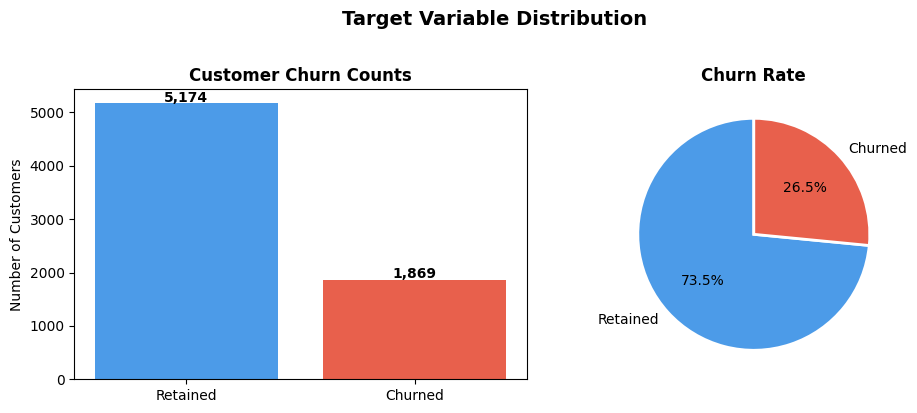

Churn rate: 26.5%  |  Class imbalance ratio: 1:2.8


In [11]:
churn_counts = df_raw['Churn Value'].value_counts()
churn_pct = churn_counts / len(df_raw) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar([CHURN_LABELS[k] for k in churn_counts.index],
            churn_counts.values,
            color=[CHURN_PALETTE[k] for k in churn_counts.index])
axes[0].set_title('Customer Churn Counts', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(churn_counts.values,
            labels=[CHURN_LABELS[k] for k in churn_counts.index],
            autopct='%1.1f%%',
            colors=[CHURN_PALETTE[k] for k in churn_counts.index],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Churn Rate', fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/01_target_distribution.png', bbox_inches='tight')
plt.show()

print(f'Churn rate: {churn_pct[1]:.1f}%  |  Class imbalance ratio: 1:{churn_counts[0]/churn_counts[1]:.1f}')

---
## 3. Data Cleaning & Preprocessing

In [12]:
df = df_raw.copy()

df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
print(f"Total Charges NaN after conversion: {df['Total Charges'].isna().sum()}")

print(df[df['Total Charges'].isna()][['Tenure Months', 'Monthly Charges', 'Total Charges']].head())
df['Total Charges'].fillna(0, inplace=True)

Total Charges NaN after conversion: 11
      Tenure Months  Monthly Charges  Total Charges
2234              0            52.55            NaN
2438              0            20.25            NaN
2568              0            80.85            NaN
2667              0            25.75            NaN
2856              0            56.05            NaN


In [13]:
drop_cols = [
    'CustomerID',
    'Count',
    'Country',
    'State',
    'Lat Long',
    'Churn Label',
    'Churn Score',
    'Churn Reason'
]

df.drop(columns=drop_cols, inplace=True)
print(f'Remaining columns: {df.shape[1]}')
print(df.columns.tolist())

Remaining columns: 25
['City', 'Zip Code', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value', 'CLTV']


In [14]:
binary_cols = ['Partner', 'Dependents', 'Phone Service', 'Paperless Billing', 'Senior Citizen']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df[binary_cols + ['Gender']].head()

,Partner,Dependents,Phone Service,Paperless Billing,Senior Citizen,Gender
0,0,0,1,1,0,1
1,0,1,1,1,0,0
2,0,1,1,1,0,0
3,1,1,1,1,0,0
4,0,1,1,1,0,1


In [15]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f'{col:20s}: {df[col].unique().tolist()}')

City                : ['Los Angeles', 'Beverly Hills', 'Huntington Park', 'Lynwood', 'Marina Del Rey', 'Inglewood', 'Santa Monica', 'Torrance', 'Whittier', 'La Habra', 'Pico Rivera', 'Avalon', 'Harbor City', 'Lakewood', 'Los Alamitos', 'San Pedro', 'Carson', 'Long Beach', 'Altadena', 'Monrovia', 'Sierra Madre', 'Tujunga', 'Pasadena', 'Glendale', 'Canoga Park', 'Mission Hills', 'Santa Clarita', 'Sun Valley', 'Stevenson Ranch', 'Panorama City', 'Van Nuys', 'Burbank', 'North Hollywood', 'Covina', 'El Monte', 'La Puente', 'Rowland Heights', 'Ontario', 'Pomona', 'Rosemead', 'San Dimas', 'West Covina', 'Alhambra', 'Alpine', 'Bonita', 'Boulevard', 'Guatay', 'Jacumba', 'Mount Laguna', 'Borrego Springs', 'Carlsbad', 'Del Mar', 'El Cajon', 'Escondido', 'Oceanside', 'Pala', 'Palomar Mountain', 'Pauma Valley', 'Ranchita', 'Valley Center', 'San Diego', 'Indio', 'Indian Wells', 'Palm Desert', 'Desert Hot Springs', 'Holtville', 'Niland', 'North Palm Springs', 'Ocotillo', 'Seeley', 'Thermal', 'Adelant

In [16]:
df.isnull().sum()

City                 0
Zip Code             0
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Value          0
CLTV                 0
dtype: int64

---
## 4. Exploratory Data Analysis (EDA)
### 4.1 Demographics

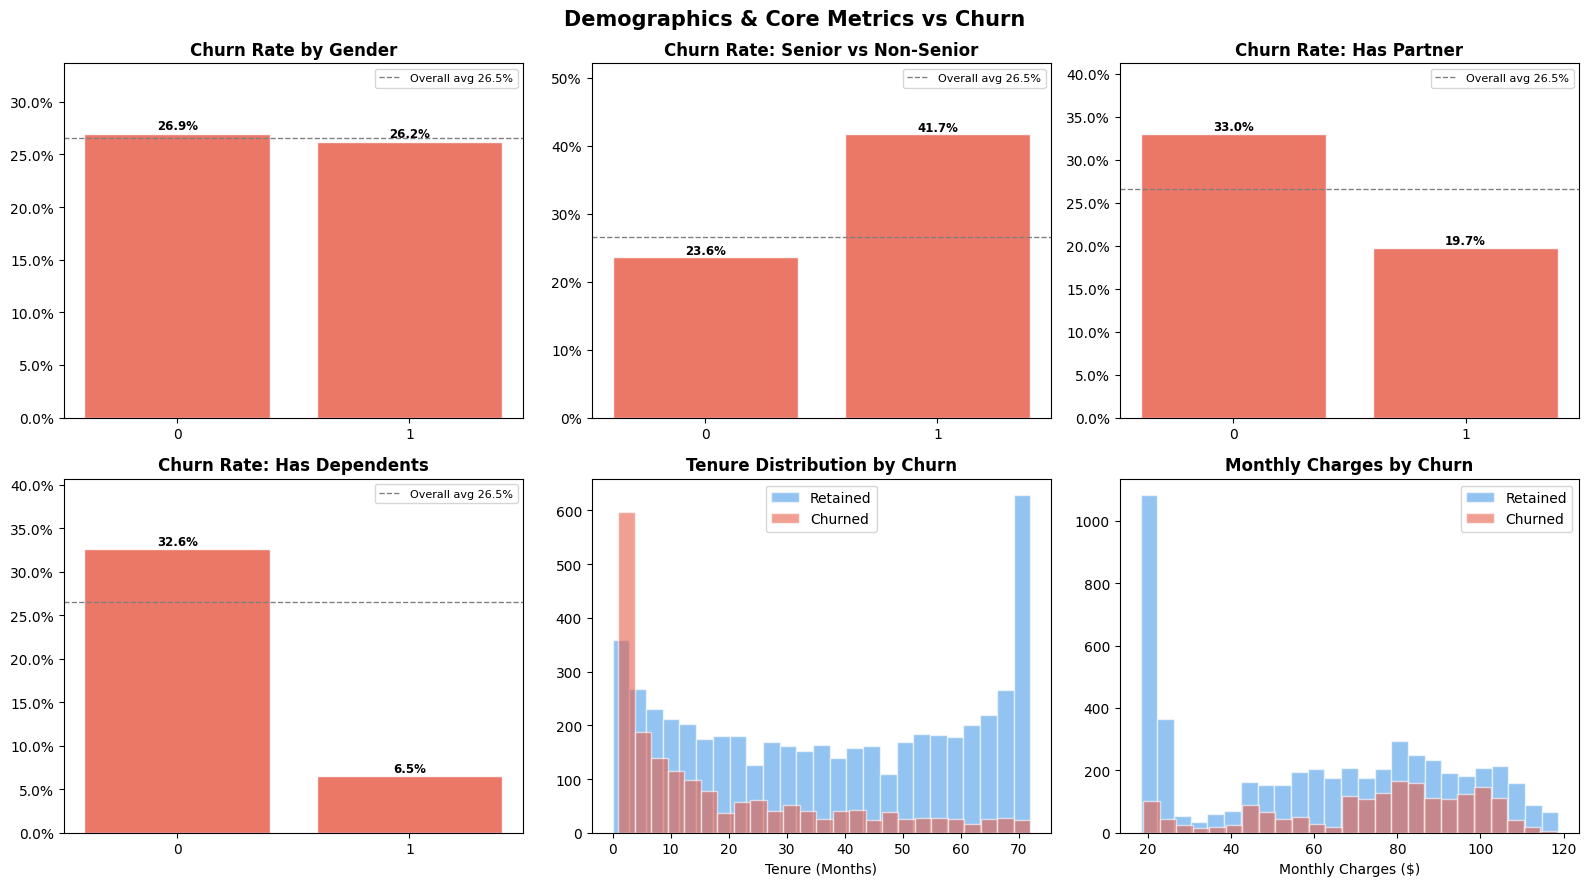

In [17]:
def churn_rate_barplot(col, ax, title=None, order=None, df=df):
    grp = df.groupby(col)['Churn Value'].agg(['mean', 'count']).reset_index()
    grp['churn_pct'] = grp['mean'] * 100
    if order:
        grp[col] = pd.Categorical(grp[col], categories=order, ordered=True)
        grp = grp.sort_values(col)
    bars = ax.bar(grp[col].astype(str), grp['churn_pct'],
                  color='#E8604C', alpha=0.85, edgecolor='white')
    ax.axhline(df['Churn Value'].mean()*100, color='grey', linestyle='--',
               linewidth=1, label=f'Overall avg {df["Churn Value"].mean()*100:.1f}%')
    ax.set_ylim(0, grp['churn_pct'].max() * 1.25)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(title or col, fontweight='bold')
    ax.legend(fontsize=8)
    for bar, (_, row) in zip(bars, grp.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{row["churn_pct"]:.1f}%', ha='center', fontsize=8.5, fontweight='bold')


fig, axes = plt.subplots(2, 3, figsize=(16, 9))

churn_rate_barplot('Gender', axes[0,0], 'Churn Rate by Gender')
churn_rate_barplot('Senior Citizen', axes[0,1], 'Churn Rate: Senior vs Non-Senior')
churn_rate_barplot('Partner', axes[0,2], 'Churn Rate: Has Partner')
churn_rate_barplot('Dependents', axes[1,0], 'Churn Rate: Has Dependents')

# Tenure distribution by churn
for churn_val, label in CHURN_LABELS.items():
    subset = df[df['Churn Value'] == churn_val]['Tenure Months']
    axes[1,1].hist(subset, bins=25, alpha=0.6, label=label, 
                   color=CHURN_PALETTE[churn_val], edgecolor='white')
axes[1,1].set_title('Tenure Distribution by Churn', fontweight='bold')
axes[1,1].set_xlabel('Tenure (Months)')
axes[1,1].legend()

# Monthly charges distribution
for churn_val, label in CHURN_LABELS.items():
    subset = df[df['Churn Value'] == churn_val]['Monthly Charges']
    axes[1,2].hist(subset, bins=25, alpha=0.6, label=label,
                   color=CHURN_PALETTE[churn_val], edgecolor='white')
axes[1,2].set_title('Monthly Charges by Churn', fontweight='bold')
axes[1,2].set_xlabel('Monthly Charges ($)')
axes[1,2].legend()

plt.suptitle('Demographics & Core Metrics vs Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('images/02_demographics_eda.png', bbox_inches='tight')
plt.show()

### 4.2 Services Analysis

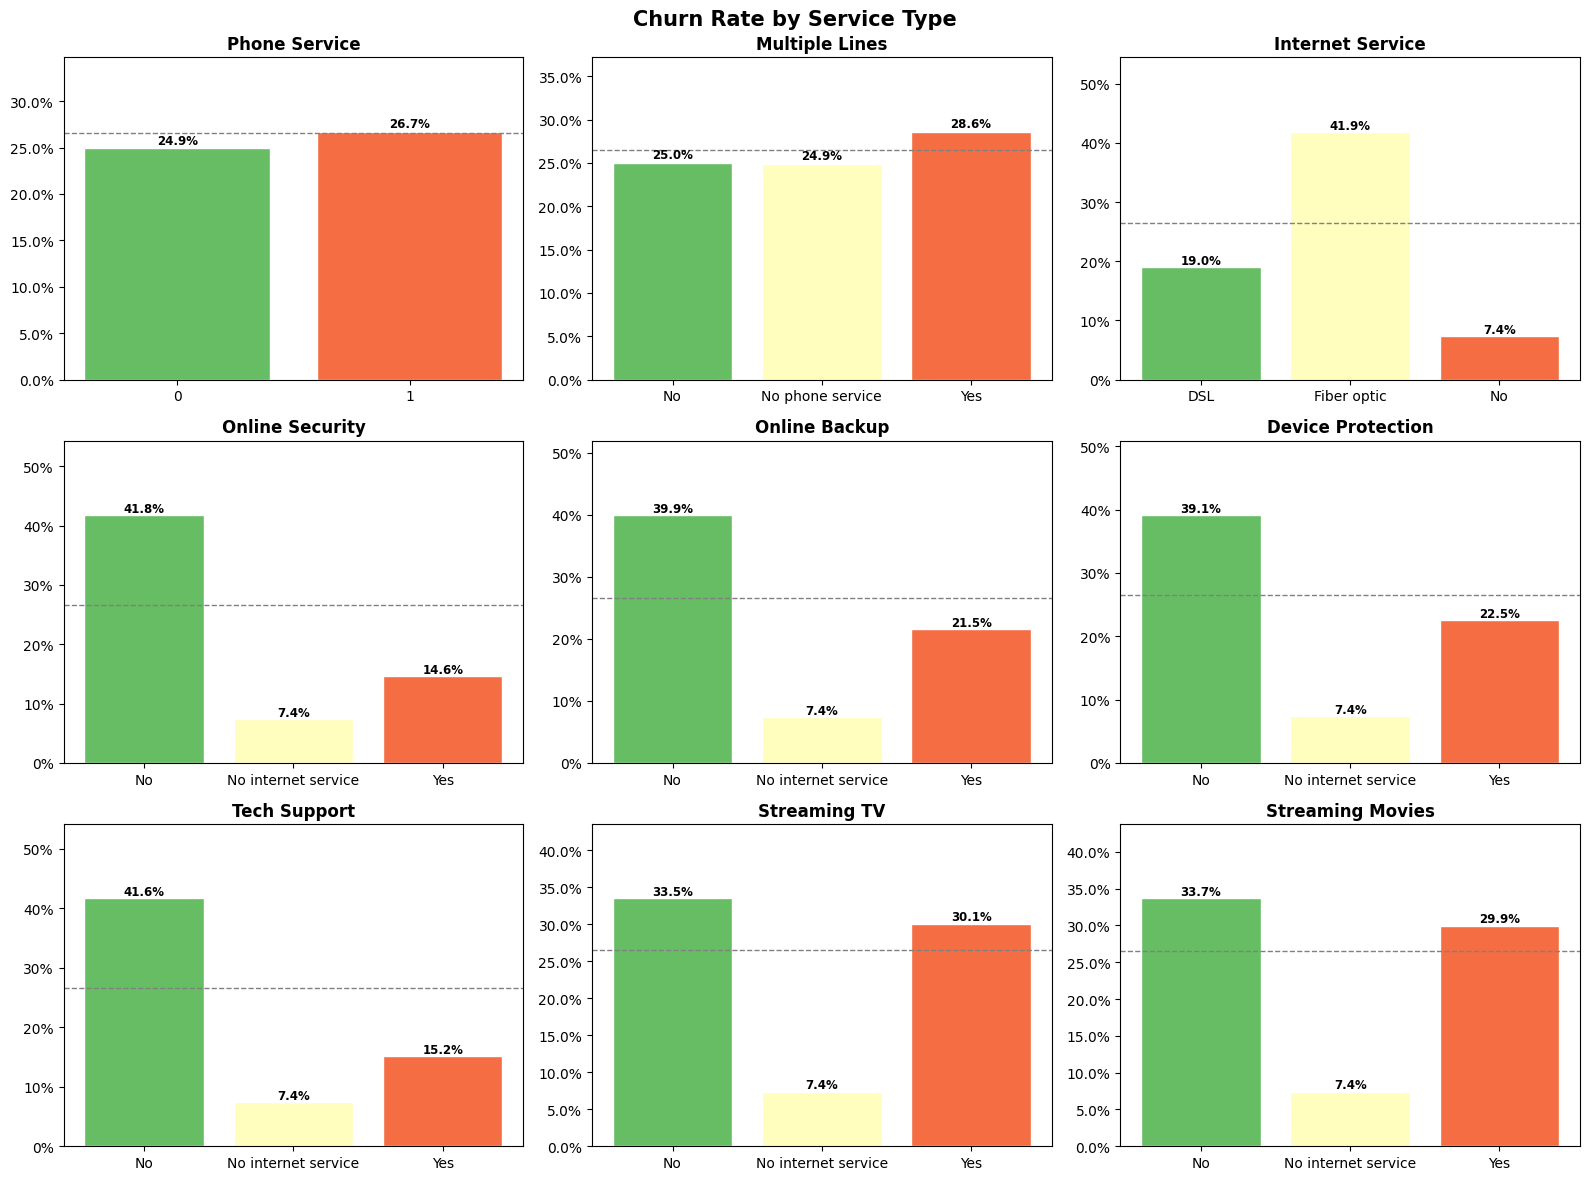

In [18]:
service_cols = [
    'Phone Service', 'Multiple Lines', 'Internet Service',
    'Online Security', 'Online Backup', 'Device Protection',
    'Tech Support', 'Streaming TV', 'Streaming Movies'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(service_cols):
    grp = df.groupby(col)['Churn Value'].mean().reset_index()
    grp['churn_pct'] = grp['Churn Value'] * 100
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(grp)))
    bars = axes[i].bar(grp[col].astype(str), grp['churn_pct'],
                       color=colors, edgecolor='white')
    axes[i].axhline(df['Churn Value'].mean()*100, color='grey', linestyle='--', linewidth=1)
    axes[i].set_title(col, fontweight='bold')
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i].set_ylim(0, grp['churn_pct'].max() * 1.3)
    for bar, val in zip(bars, grp['churn_pct']):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', fontsize=8.5, fontweight='bold')

plt.suptitle('Churn Rate by Service Type', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('images/03_services_eda.png', bbox_inches='tight')
plt.show()

### 4.3 Contract & Payment Analysis

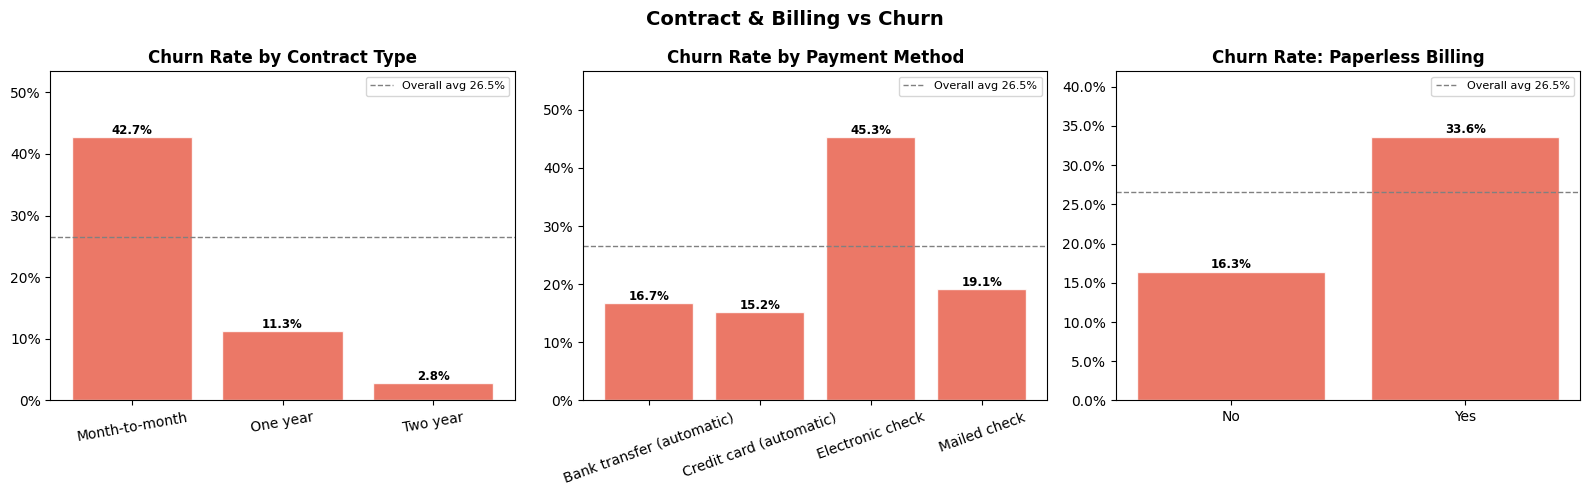

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Contract type
contract_order = ['Month-to-month', 'One year', 'Two year']
churn_rate_barplot('Contract', axes[0], 'Churn Rate by Contract Type', order=contract_order)
axes[0].tick_params(axis='x', rotation=10)

# Payment method
churn_rate_barplot('Payment Method', axes[1], 'Churn Rate by Payment Method')
axes[1].tick_params(axis='x', rotation=20)

# Paperless billing
churn_rate_barplot('Paperless Billing', axes[2], 'Churn Rate: Paperless Billing')
axes[2].set_xticklabels(['No', 'Yes'])

plt.suptitle('Contract & Billing vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/04_contract_billing_eda.png', bbox_inches='tight')
plt.show()

### 4.4 Financial Analysis

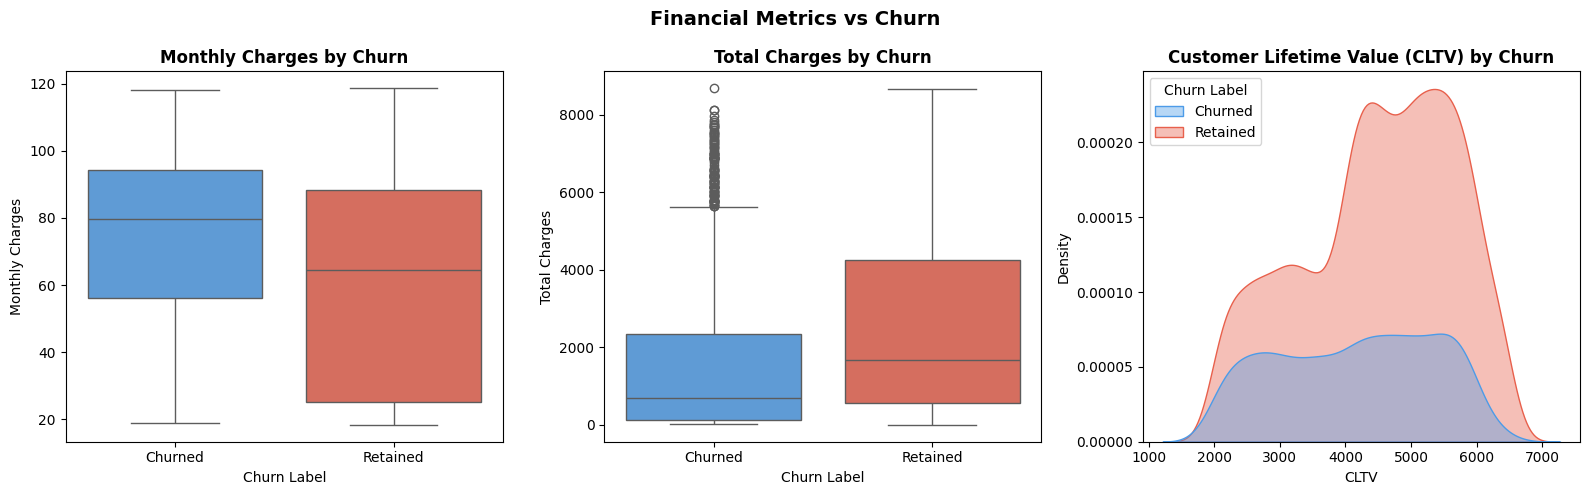

,Monthly Charges,Total Charges,Tenure Months,CLTV
Churn Label,,,,
Churned,74.44,1531.80,17.98,4149.41
Retained,61.27,2549.91,37.57,4490.92


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Box plots: monthly charges
df['Churn Label'] = df['Churn Value'].map(CHURN_LABELS)
sns.boxplot(data=df, x='Churn Label', y='Monthly Charges',
            palette=list(CHURN_PALETTE.values()), ax=axes[0])
axes[0].set_title('Monthly Charges by Churn', fontweight='bold')

# Box plots: total charges
sns.boxplot(data=df, x='Churn Label', y='Total Charges',
            palette=list(CHURN_PALETTE.values()), ax=axes[1])
axes[1].set_title('Total Charges by Churn', fontweight='bold')

# CLTV distribution
sns.kdeplot(data=df, x='CLTV', hue='Churn Label',
            palette=list(CHURN_PALETTE.values()), fill=True, alpha=0.4, ax=axes[2])
axes[2].set_title('Customer Lifetime Value (CLTV) by Churn', fontweight='bold')

plt.suptitle('Financial Metrics vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/05_financial_eda.png', bbox_inches='tight')
plt.show()

# Numeric summary
df.groupby('Churn Label')[['Monthly Charges', 'Total Charges', 'Tenure Months', 'CLTV']].mean().round(2)

### 4.5 Churn Reasons Analysis (Churned Customers Only)

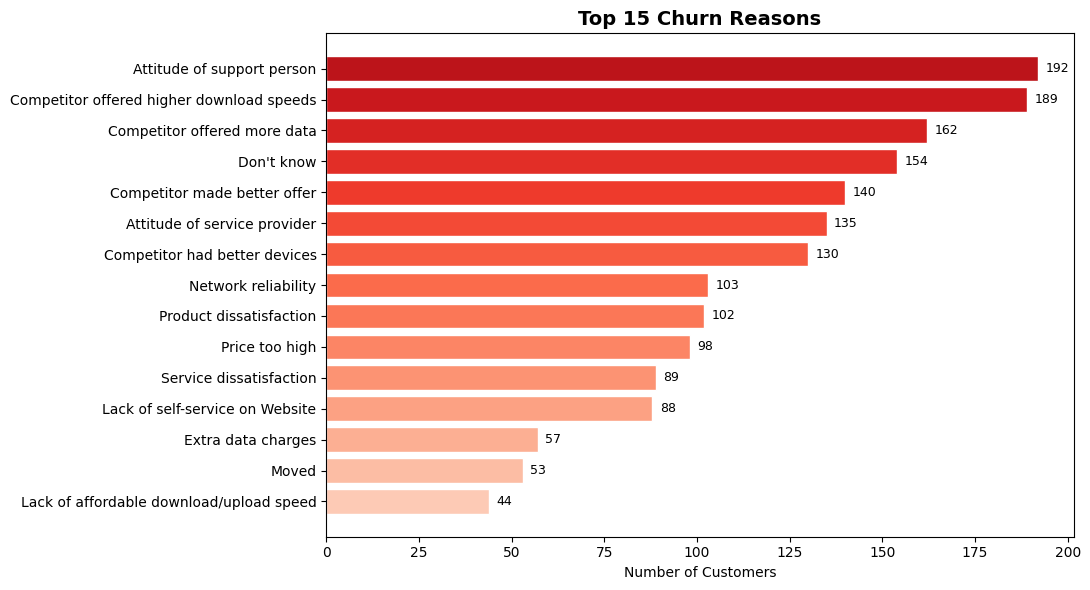

In [21]:
# Use raw data to get churn reasons (dropped from modelling df)
churned = df_raw[df_raw['Churn Value'] == 1].copy()
reasons = churned['Churn Reason'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(11, 6))
colors = plt.cm.Reds_r(np.linspace(0.2, 0.8, len(reasons)))
bars = ax.barh(reasons.index[::-1], reasons.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('Number of Customers')
ax.set_title('Top 15 Churn Reasons', fontweight='bold', fontsize=14)
for bar, val in zip(bars, reasons.values[::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('images/06_churn_reasons.png', bbox_inches='tight')
plt.show()

### 4.6 Correlation Analysis

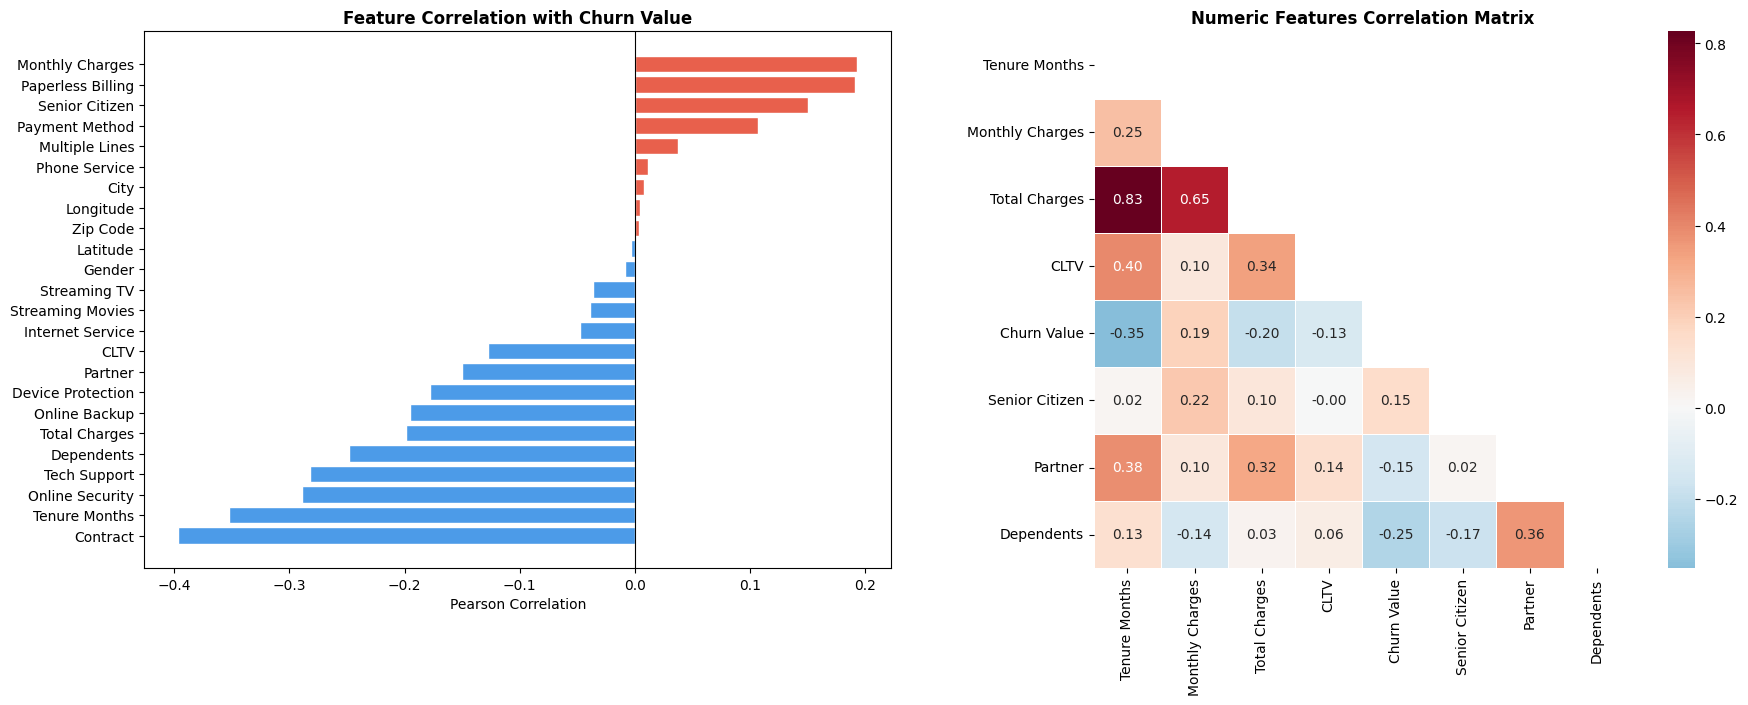

In [22]:
# Temporarily encode all categoricals for correlation
df_enc = df.drop(columns=['Churn Label'], errors='ignore').copy()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))

corr = df_enc.corr()

# Correlations with target
target_corr = corr['Churn Value'].drop('Churn Value').sort_values()
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart: correlation with churn
colors = ['#E8604C' if v > 0 else '#4C9BE8' for v in target_corr.values]
axes[0].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Feature Correlation with Churn Value', fontweight='bold')
axes[0].set_xlabel('Pearson Correlation')

# Heatmap
numeric_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV',
                'Churn Value', 'Senior Citizen', 'Partner', 'Dependents']
corr_sub = df_enc[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_sub, dtype=bool))
sns.heatmap(corr_sub, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[1], linewidths=0.5, square=True)
axes[1].set_title('Numeric Features Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('images/07_correlation.png', bbox_inches='tight')
plt.show()

---
## 5. Feature Engineering

New features created:
  • Avg Monthly Spend
  • VAS Count (value-added services)
  • Streaming Count
  • Long Term Contract
  • Tenure Bucket


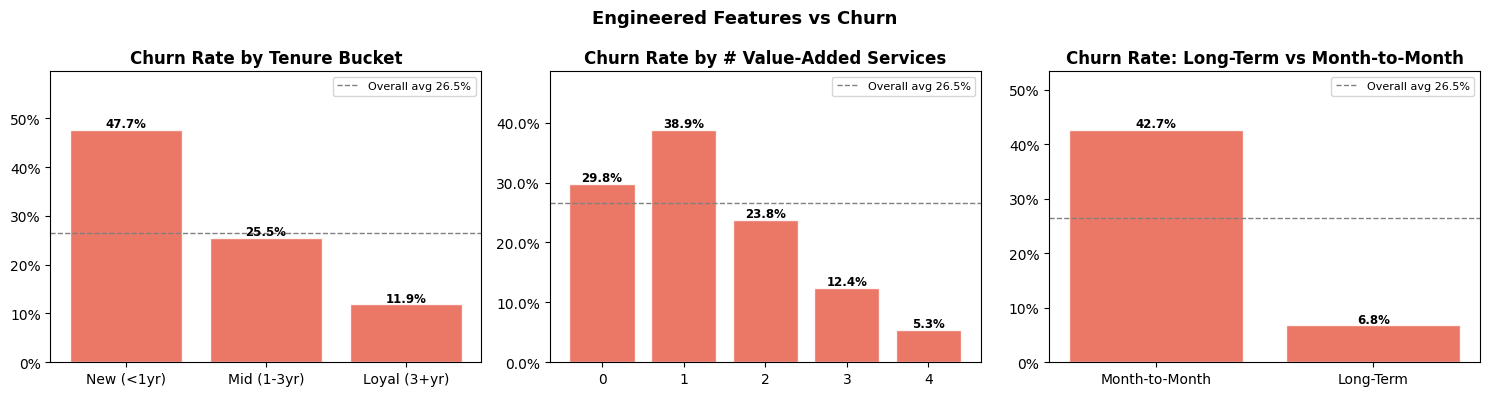

In [23]:
df_feat = df.drop(columns=['Churn Label'], errors='ignore').copy()

# Avg monthly charge per tenure month (spend efficiency)
df_feat['Avg Monthly Spend'] = df_feat['Total Charges'] / (df_feat['Tenure Months'] + 1)

# Count of value-added services (online security, backup, device protection, tech support)
vas_cols = ['Online Security', 'Online Backup', 'Device Protection', 'Tech Support']
df_feat['VAS Count'] = df_feat[vas_cols].apply(
    lambda row: sum(v == 'Yes' for v in row), axis=1
)

# Count of streaming services
streaming_cols = ['Streaming TV', 'Streaming Movies']
df_feat['Streaming Count'] = df_feat[streaming_cols].apply(
    lambda row: sum(v == 'Yes' for v in row), axis=1
)

# Is the customer on a long-term contract?
df_feat['Long Term Contract'] = df_feat['Contract'].apply(
    lambda x: 1 if x in ['One year', 'Two year'] else 0
)

# Tenure bucket: new (< 12), mid (12–36), loyal (> 36)
df_feat['Tenure Bucket'] = pd.cut(
    df_feat['Tenure Months'], bins=[0, 12, 36, 72],
    labels=['New (<1yr)', 'Mid (1-3yr)', 'Loyal (3+yr)'], right=True
)

print('New features created:')
print('  • Avg Monthly Spend')
print('  • VAS Count (value-added services)')
print('  • Streaming Count')
print('  • Long Term Contract')
print('  • Tenure Bucket')

# Visualise feature distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

churn_rate_barplot('Tenure Bucket', axes[0], 'Churn Rate by Tenure Bucket',
                   order=['New (<1yr)', 'Mid (1-3yr)', 'Loyal (3+yr)'], df=df_feat)
churn_rate_barplot('VAS Count', axes[1], 'Churn Rate by # Value-Added Services', df=df_feat)
churn_rate_barplot('Long Term Contract', axes[2], 'Churn Rate: Long-Term vs Month-to-Month', df=df_feat)
axes[2].set_xticklabels(['Month-to-Month', 'Long-Term'])

plt.suptitle('Engineered Features vs Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/08_feature_engineering.png', bbox_inches='tight')
plt.show()

---
## 6. Model Building
### 6.1 Data Preparation

In [24]:
# Drop geo columns (too granular, not meaningful without geo-model)
# Drop Tenure Bucket (ordinal, captured better by Tenure Months + VAS count)
drop_for_model = [
    'Country', 'State', 'City', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Bucket'
]
df_model = df_feat.drop(columns=drop_for_model, errors='ignore')

# One-hot encode remaining categoricals
cat_model_cols = df_model.select_dtypes(include='object').columns.tolist()
print('Columns to one-hot encode:', cat_model_cols)

df_model = pd.get_dummies(df_model, columns=cat_model_cols, drop_first=True)
print(f'Feature matrix shape after encoding: {df_model.shape}')

Columns to one-hot encode: ['Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Payment Method']
Feature matrix shape after encoding: (7043, 36)


In [25]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 36 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Gender                                  7043 non-null   int64  
 1   Senior Citizen                          7043 non-null   int64  
 2   Partner                                 7043 non-null   int64  
 3   Dependents                              7043 non-null   int64  
 4   Tenure Months                           7043 non-null   int64  
 5   Phone Service                           7043 non-null   int64  
 6   Paperless Billing                       7043 non-null   int64  
 7   Monthly Charges                         7043 non-null   float64
 8   Total Charges                           7043 non-null   float64
 9   Churn Value                             7043 non-null   int64  
 10  CLTV                                    7043 non-null   int6

In [26]:
X = df_model.drop(columns=['Churn Value'])
y = df_model['Churn Value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]:,} samples ({y_train.mean()*100:.1f}% churn)')
print(f'Test set     : {X_test.shape[0]:,} samples ({y_test.mean()*100:.1f}% churn)')

Training set : 5,634 samples (26.5% churn)
Test set     : 1,409 samples (26.5% churn)


In [27]:
# Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Class weights to handle imbalance
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
cw_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", cw_dict)

Class weights: {0: np.float64(0.6805991785455424), 1: np.float64(1.8842809364548494)}


### 6.2 Model Training

In [28]:
feature_selector = SelectFromModel(
    RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    threshold="median"
)

pipelines = {
    "Logistic Regression": Pipeline([
        ("feature_selection", feature_selector),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("feature_selection", feature_selector),
        ("model", RandomForestClassifier(
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("feature_selection", feature_selector),
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ]),

    "SVM": Pipeline([
        ("feature_selection", feature_selector),
        ("model", SVC(
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
    ])
}

param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10]
    },

    "Random Forest": {
        "model__n_estimators": [200,300,400],
        "model__max_depth": [6,10,14,None],
        "model__min_samples_split": [2,5,10]
    },

    "Gradient Boosting": {
        "model__n_estimators": [150,200,300],
        "model__learning_rate": [0.01,0.05,0.1],
        "model__max_depth": [3,4,5]
    },

    "SVM": {
        "model__C": [0.1,1,10],
        "model__gamma": ["scale","auto"]
    }
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name in pipelines:
    print(f"\nTraining {name}")

    search = RandomizedSearchCV(
        pipelines[name],
        param_distributions=param_grids[name],
        n_iter=10,
        scoring="roc_auc",
        cv=cv,
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:,1]

    cv_scores = cross_val_score(
        best_model,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc"
    )

    results[name] = {
        "model": best_model,
        "y_pred": y_pred,
        "y_proba": y_proba,

        "accuracy": accuracy_score(y_test,y_pred),
        "precision": precision_score(y_test,y_pred),
        "recall": recall_score(y_test,y_pred),
        "f1": f1_score(y_test,y_pred),

        "roc_auc": roc_auc_score(y_test,y_proba),

        "cv_roc_auc": cv_scores.mean(),
        "cv_std": cv_scores.std()
    }

    print("Best params:", search.best_params_)
    print(f"AUC={results[name]['roc_auc']:.4f} | F1={results[name]['f1']:.4f}")


Training Logistic Regression
Best params: {'model__C': 1}
AUC=0.8488 | F1=0.6221

Training Random Forest
Best params: {'model__n_estimators': 400, 'model__min_samples_split': 10, 'model__max_depth': 10}
AUC=0.8536 | F1=0.6438

Training Gradient Boosting
Best params: {'model__n_estimators': 150, 'model__max_depth': 3, 'model__learning_rate': 0.05}
AUC=0.8525 | F1=0.5816

Training SVM
Best params: {'model__gamma': 'scale', 'model__C': 10}
AUC=0.8048 | F1=0.5801


In [29]:
best_model_name = max(results, key=lambda x: results[x]["roc_auc"])
best_model = results[best_model_name]["model"]

y_probs = best_model.predict_proba(X_test)[:,1]
thresholds = np.arange(0.1,0.9,0.01)
f1_scores = []

for t in thresholds:
    preds = (y_probs >= t).astype(int)
    f1_scores.append(f1_score(y_test,preds))

best_threshold = thresholds[np.argmax(f1_scores)]

print("Best model:", best_model_name)
print("Optimal threshold:", round(best_threshold,3))
print("Best F1:", max(f1_scores))

Best model: Random Forest
Optimal threshold: 0.49
Best F1: 0.6462585034013606


---
## 7. Model Evaluation & Comparison

In [30]:
metrics_df = pd.DataFrame([
    {
        'Model': name,
        'Accuracy':  f"{v['accuracy']:.4f}",
        'Precision': f"{v['precision']:.4f}",
        'Recall':    f"{v['recall']:.4f}",
        'F1-Score':  f"{v['f1']:.4f}",
        'ROC-AUC':   f"{v['roc_auc']:.4f}",
        'CV ROC-AUC':f"{v['cv_roc_auc']:.4f} ± {v['cv_std']:.4f}"
    }
    for name, v in results.items()
])
metrics_df.set_index('Model', inplace=True)
metrics_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV ROC-AUC
Model,,,,,,
Logistic Regression,0.7431,0.5103,0.7968,0.6221,0.8488,0.8586 ± 0.0125
Random Forest,0.7793,0.5631,0.7513,0.6438,0.8536,0.8605 ± 0.0104
Gradient Boosting,0.7999,0.6533,0.5241,0.5816,0.8525,0.8610 ± 0.0096
SVM,0.6969,0.4588,0.7888,0.5801,0.8048,0.7797 ± 0.0123


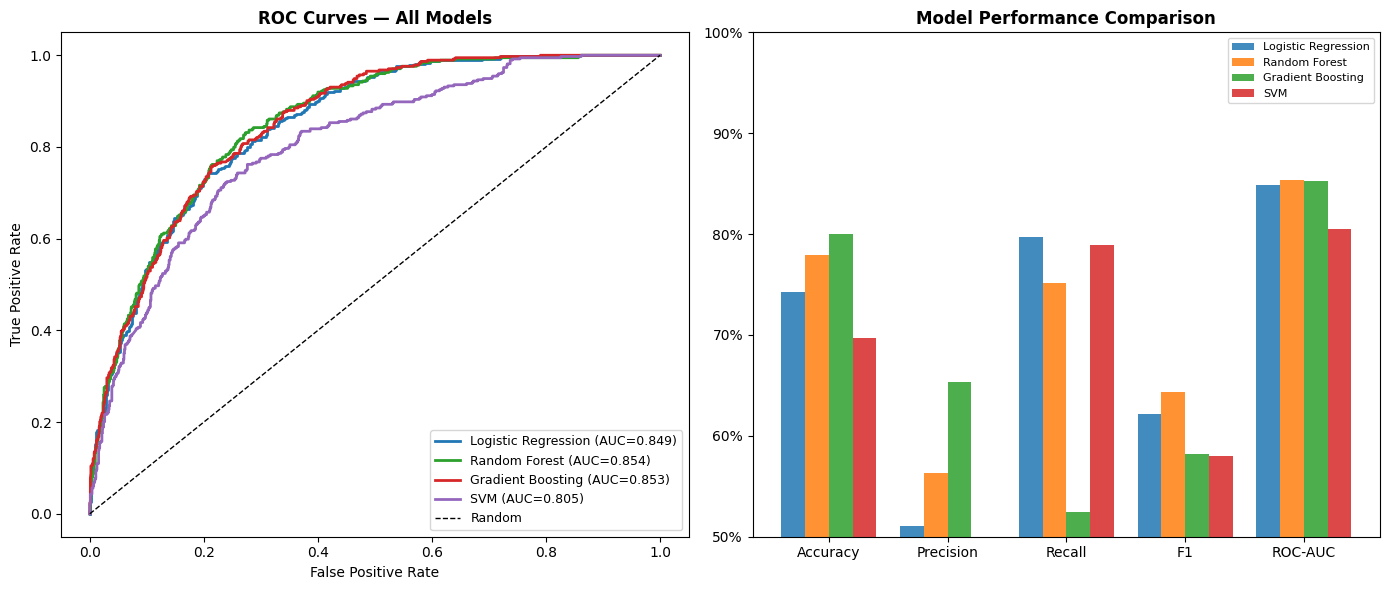

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_roc = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']
for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})", color=color, lw=2)
axes[0].plot([0,1], [0,1], 'k--', linewidth=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models', fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)

# Bar chart comparison
metric_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(metric_names))
width = 0.2
for i, (name, res) in enumerate(results.items()):
    vals = [res[m] for m in metric_names]
    axes[1].bar(x + i*width, vals, width, label=name, alpha=0.85)
axes[1].set_xticks(x + width*1.5)
axes[1].set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'])
axes[1].set_ylim(0.5, 1.0)
axes[1].set_title('Model Performance Comparison', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig('images/09_roc_comparison.png', bbox_inches='tight')
plt.show()

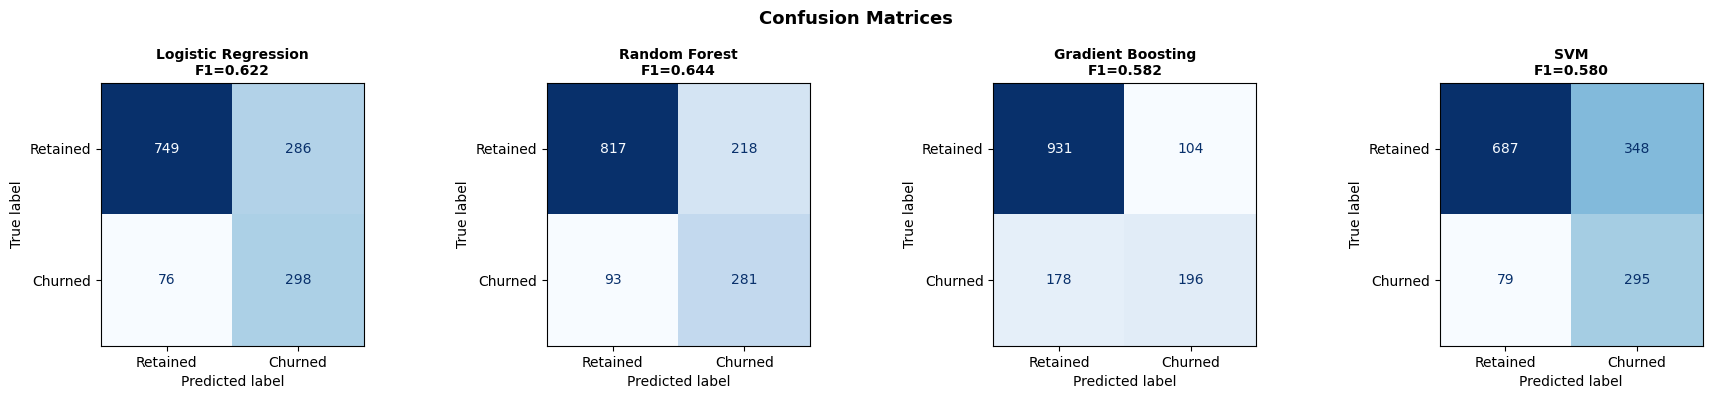

In [32]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nF1={res["f1"]:.3f}', fontweight='bold', fontsize=10)

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/10_confusion_matrices.png', bbox_inches='tight')
plt.show()

In [33]:
# Best Model Classification by ROC-AUC
best_name = max(results, key=lambda k: results[k]['roc_auc'])
best = results[best_name]
print(f'🏆 Best Model: {best_name}  (ROC-AUC = {best["roc_auc"]:.4f})')
print('=' * 55)
print(classification_report(y_test, best['y_pred'], target_names=['Retained', 'Churned']))

🏆 Best Model: Random Forest  (ROC-AUC = 0.8536)
              precision    recall  f1-score   support

    Retained       0.90      0.79      0.84      1035
     Churned       0.56      0.75      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.78      0.79      1409



---
## 8. Feature Importance Analysis

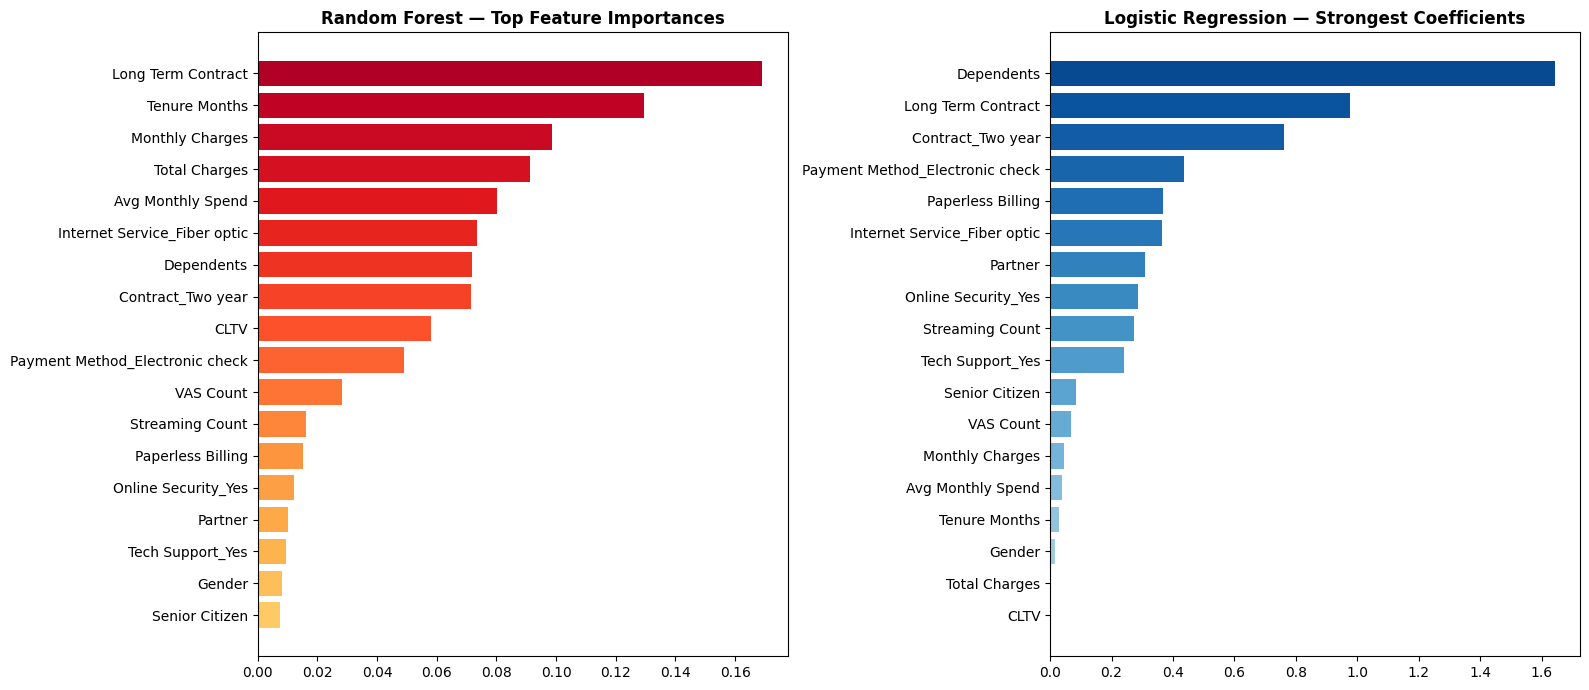

In [34]:
# Random Forest
rf_pipeline = results['Random Forest']['model']
rf_selector = rf_pipeline.named_steps['feature_selection']
rf_model = rf_pipeline.named_steps['model']
rf_features = X.columns[rf_selector.get_support()]

rf_importances = pd.Series(
    rf_model.feature_importances_,
    index=rf_features
).sort_values(ascending=False).head(20)

# Logistic Regression
lr_pipeline = results['Logistic Regression']['model']
lr_selector = lr_pipeline.named_steps['feature_selection']
lr_model = lr_pipeline.named_steps['model']
lr_features = X.columns[lr_selector.get_support()]

lr_coefs = pd.Series(
    np.abs(lr_model.coef_[0]),
    index=lr_features
).sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(16,7))

# RF plot
axes[0].barh(rf_importances.index[::-1], rf_importances.values[::-1],
             color=plt.cm.YlOrRd(np.linspace(0.3,0.9,len(rf_importances))))
axes[0].set_title("Random Forest — Top Feature Importances", fontweight='bold')

# LR plot
axes[1].barh(lr_coefs.index[::-1], lr_coefs.values[::-1],
             color=plt.cm.Blues(np.linspace(0.3,0.9,len(lr_coefs))))
axes[1].set_title("Logistic Regression — Strongest Coefficients", fontweight='bold')

plt.tight_layout()
plt.savefig('images/11_feature_importance.png', bbox_inches='tight')
plt.show()

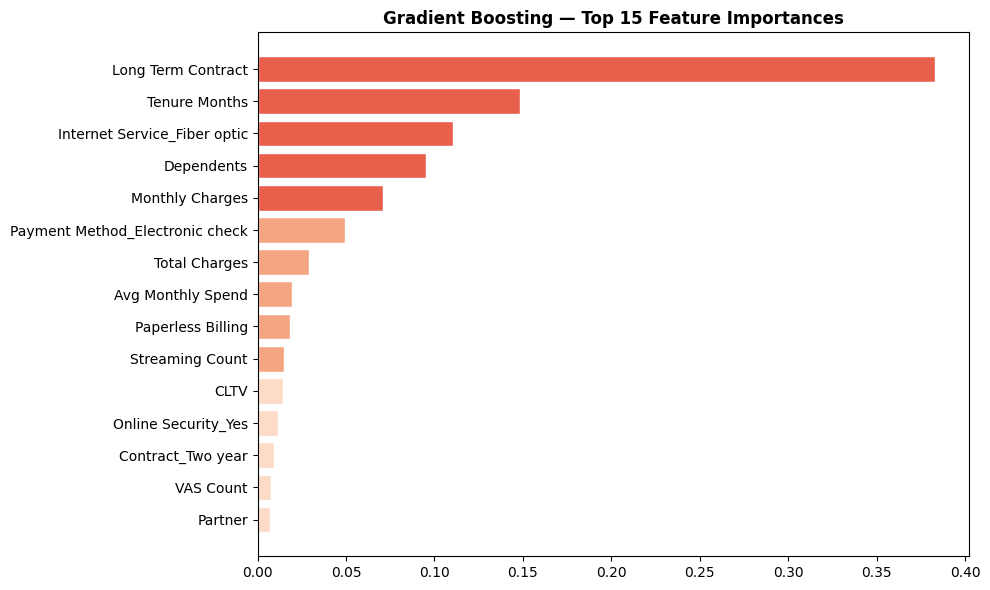

In [35]:
# Gradient Boosting Feature Importance
gb_pipeline = results['Gradient Boosting']['model']
gb_selector = gb_pipeline.named_steps['feature_selection']
gb_model = gb_pipeline.named_steps['model']
gb_features = X.columns[gb_selector.get_support()]

gb_importances = pd.Series(
    gb_model.feature_importances_,
    index=gb_features
).sort_values(ascending=False).head(15)


fig, ax = plt.subplots(figsize=(10,6))
colors = ['#E8604C' if i < 5 else '#F4A582' if i < 10 else '#FDDBC7'
          for i in range(len(gb_importances))]

ax.barh(
    gb_importances.index[::-1],
    gb_importances.values[::-1],
    color=colors[::-1],
    edgecolor='white'
)

ax.set_title(
    "Gradient Boosting — Top 15 Feature Importances",
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('images/12_gb_feature_importance.png', bbox_inches='tight')
plt.show()

---
## 9. Churn Risk Segmentation

In [36]:
# Churn Risk Segmentation
best_pipeline = results[best_name]['model']

# pipeline сам выполнит feature selection
df_feat['Churn Probability'] = best_pipeline.predict_proba(X)[:,1]

df_feat['Risk Segment'] = pd.cut(
    df_feat['Churn Probability'],
    bins=[0,0.3,0.6,1.0],
    labels=['Low Risk','Medium Risk','High Risk']
)

risk_summary = df_feat.groupby('Risk Segment', observed=True).agg(
    Customers=('Churn Probability','count'),
    Avg_Probability=('Churn Probability','mean')
)

risk_summary

,Customers,Avg_Probability
Risk Segment,,
Low Risk,3598,0.097677
Medium Risk,1411,0.451400
High Risk,2034,0.771593


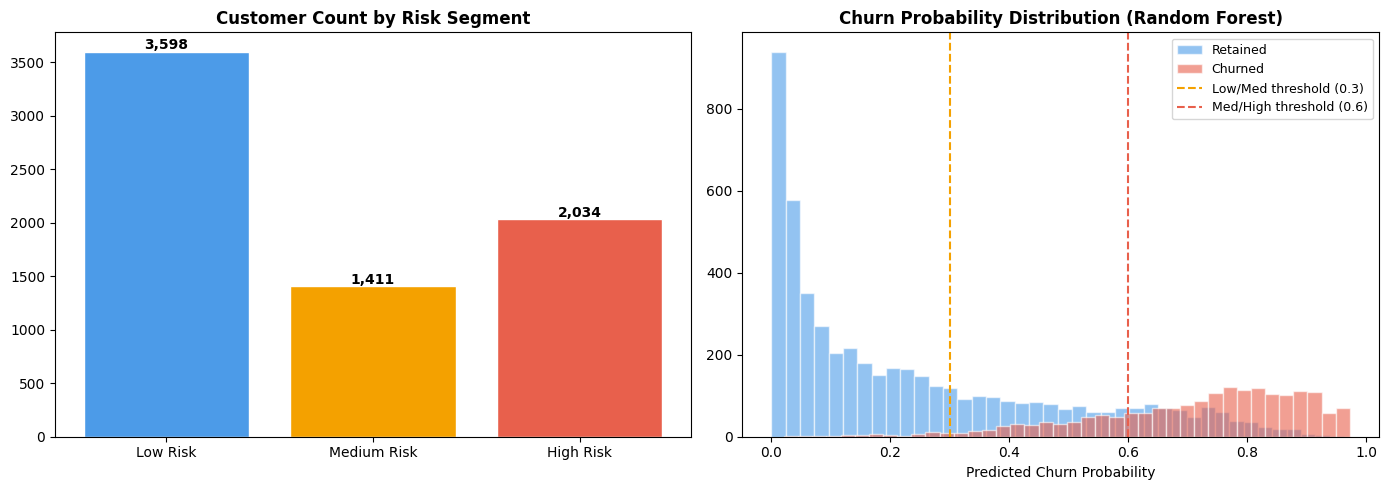

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_colors = {'Low Risk': '#4C9BE8', 'Medium Risk': '#F4A100', 'High Risk': '#E8604C'}
seg_counts = df_feat['Risk Segment'].value_counts().reindex(['Low Risk', 'Medium Risk', 'High Risk'])
axes[0].bar(seg_counts.index, seg_counts.values,
            color=[seg_colors[k] for k in seg_counts.index], edgecolor='white')
axes[0].set_title('Customer Count by Risk Segment', fontweight='bold')
for i, v in enumerate(seg_counts.values):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')

axes[1].hist(df_feat[df_feat['Churn Value']==0]['Churn Probability'],
             bins=40, alpha=0.6, label='Retained', color='#4C9BE8', edgecolor='white')
axes[1].hist(df_feat[df_feat['Churn Value']==1]['Churn Probability'],
             bins=40, alpha=0.6, label='Churned', color='#E8604C', edgecolor='white')
axes[1].axvline(0.3, color='#F4A100', linestyle='--', linewidth=1.5, label='Low/Med threshold (0.3)')
axes[1].axvline(0.6, color='#E8604C', linestyle='--', linewidth=1.5, label='Med/High threshold (0.6)')
axes[1].set_xlabel('Predicted Churn Probability')
axes[1].set_title(f'Churn Probability Distribution ({best_name})', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('images/13_risk_segmentation.png', bbox_inches='tight')
plt.show()

---
## 10. Business Insights & Recommendations

### 🔑 Key Findings

| Finding | Evidence | Impact |
|---|---|---|
| **Month-to-month contracts** are the #1 structural risk factor | ~43% churn vs ~11% for annual | High |
| **Fiber optic internet** users churn significantly more | ~42% churn vs ~19% for DSL | High |
| **No value-added services** (security, backup, tech support) = high risk | Customers with 0 VAS churn 2× more | High |
| **New customers** (< 12 months tenure) are most vulnerable | First-year churn far exceeds loyal customers | High |
| **Senior citizens** churn at a higher rate | ~41% vs ~24% for non-seniors | Medium |
| **Electronic check** payment users churn more than auto-pay users | ~45% vs ~15-18% | Medium |
| **Higher monthly charges** correlate with higher churn | Churned avg $74 vs retained avg $61 | Medium |
| **Gender** has no meaningful effect on churn | Nearly identical rates | Low |

### 💡 Actionable Recommendations

**1. Contract Upgrade Campaigns**  
Target month-to-month customers (especially those 3–6 months in) with incentivised offers to switch to annual contracts. A 10–20% monthly discount for committing to a year can dramatically reduce churn exposure.

**2. Fibre Optic Satisfaction Programme**  
Fibre optic users pay more but churn more — investigate service quality issues. Proactively offer free tech support upgrades or loyalty credits to this segment.

**3. New Customer Onboarding (First 90 Days)**  
The first year is critical. Implement a structured onboarding journey: welcome calls, setup assistance, and a free trial of Online Security or Tech Support to increase stickiness.

**4. Auto-Pay Incentive**  
Electronic check customers churn at the highest rate. Offer a monthly bill discount (e.g. $5/mo) to switch to automatic bank transfer or credit card — this also reduces payment-related churn.

**5. Senior Citizen Retention Programme**  
Dedicated support line, simplified billing, and in-person or phone-based assistance for senior customers. Assign proactive account managers for this segment.

**6. High-Risk Customer Early Warning System**  
Deploy the trained churn model in production. Flag customers with predicted probability > 60% for proactive outreach by the retention team within 30 days.

### 📈 Estimated Business Impact

With **1,869 churned customers** and an average CLTV near **$3,500**, total revenue at risk ≈ **$6.5M per cycle**.  
Reducing churn by even 20% through targeted interventions = **~$1.3M in retained revenue**.


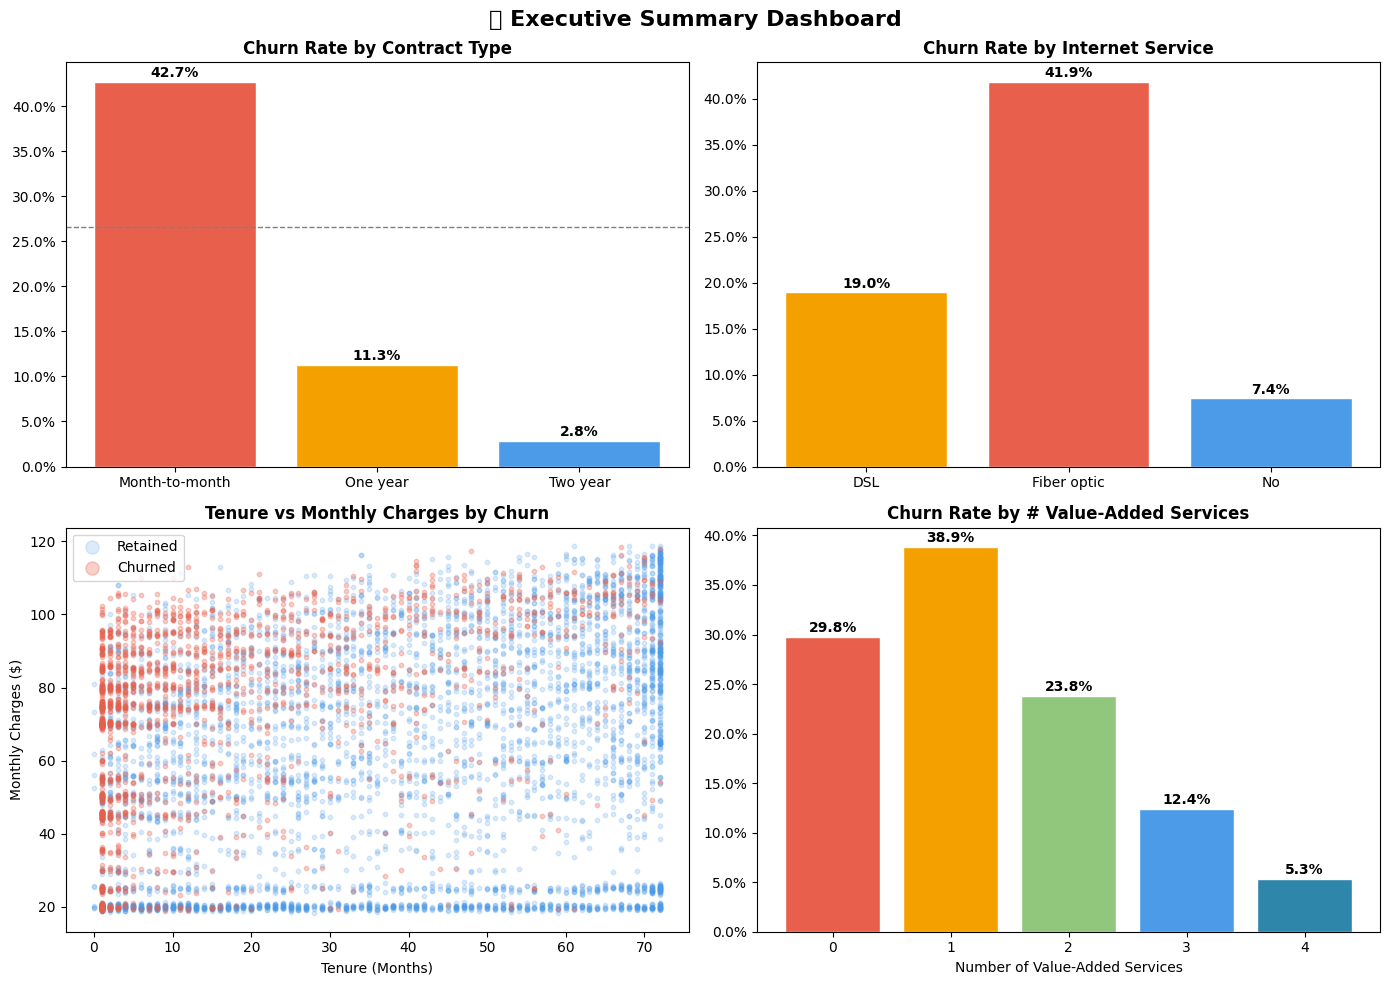

In [38]:
# Summary Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1 - Contract vs Churn
contract_churn = df.groupby('Contract')['Churn Value'].mean() * 100
contract_churn = contract_churn.reindex(['Month-to-month', 'One year', 'Two year'])
colors_c = ['#E8604C', '#F4A100', '#4C9BE8']
bars = axes[0,0].bar(contract_churn.index, contract_churn.values, color=colors_c, edgecolor='white')
axes[0,0].axhline(df['Churn Value'].mean()*100, color='grey', linestyle='--', linewidth=1)
axes[0,0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0,0].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, contract_churn.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                   f'{val:.1f}%', ha='center', fontweight='bold')

# 2 - Internet service vs Churn
inet_churn = df.groupby('Internet Service')['Churn Value'].mean() * 100
axes[0,1].bar(inet_churn.index, inet_churn.values,
              color=['#F4A100', '#E8604C', '#4C9BE8'], edgecolor='white')
axes[0,1].set_title('Churn Rate by Internet Service', fontweight='bold')
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, val in enumerate(inet_churn.values):
    axes[0,1].text(i, val+0.5, f'{val:.1f}%', ha='center', fontweight='bold')

# 3 - Tenure vs Churn (scatter)
axes[1,0].scatter(
    df[df['Churn Value']==0]['Tenure Months'],
    df[df['Churn Value']==0]['Monthly Charges'],
    alpha=0.2, s=10, color='#4C9BE8', label='Retained'
)
axes[1,0].scatter(
    df[df['Churn Value']==1]['Tenure Months'],
    df[df['Churn Value']==1]['Monthly Charges'],
    alpha=0.3, s=10, color='#E8604C', label='Churned'
)
axes[1,0].set_xlabel('Tenure (Months)')
axes[1,0].set_ylabel('Monthly Charges ($)')
axes[1,0].set_title('Tenure vs Monthly Charges by Churn', fontweight='bold')
axes[1,0].legend(markerscale=3)

# 4 - VAS vs Churn
vas_churn = df_feat.groupby('VAS Count')['Churn Value'].mean() * 100
axes[1,1].bar(vas_churn.index, vas_churn.values,
              color=['#E8604C','#F4A100','#90C77D','#4C9BE8','#2E86AB'], edgecolor='white')
axes[1,1].set_xlabel('Number of Value-Added Services')
axes[1,1].set_title('Churn Rate by # Value-Added Services', fontweight='bold')
axes[1,1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, val in enumerate(vas_churn.values):
    axes[1,1].text(i, val+0.5, f'{val:.1f}%', ha='center', fontweight='bold')

plt.suptitle('📊 Executive Summary Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('images/14_executive_dashboard.png', bbox_inches='tight')
plt.show()

In [39]:
# Final Model Comparison
print('=' * 70)
print(f"{'MODEL PERFORMANCE SUMMARY':^70}")
print('=' * 70)
print(f"{'Model':<25} {'Accuracy':>10} {'F1-Score':>10} {'ROC-AUC':>10} {'Recall':>10}")
print('-' * 70)
for name, res in sorted(results.items(), key=lambda x: x[1]['roc_auc'], reverse=True):
    flag = ' 🏆' if name == best_name else ''
    print(f"{name + flag:<27} {res['accuracy']:>9.4f} {res['f1']:>9.4f} "
          f"{res['roc_auc']:>9.4f} {res['recall']:>9.4f}")
print('=' * 70)
print(f"\n🏆 Best model: {best_name}")
print(f"   ROC-AUC : {results[best_name]['roc_auc']:.4f}")
print(f"   Recall  : {results[best_name]['recall']:.4f}  ← critical for churn (minimize missed churners)")
print(f"   F1-Score: {results[best_name]['f1']:.4f}")

                      MODEL PERFORMANCE SUMMARY                       
Model                       Accuracy   F1-Score    ROC-AUC     Recall
----------------------------------------------------------------------
Random Forest 🏆                0.7793    0.6438    0.8536    0.7513
Gradient Boosting              0.7999    0.5816    0.8525    0.5241
Logistic Regression            0.7431    0.6221    0.8488    0.7968
SVM                            0.6969    0.5801    0.8048    0.7888

🏆 Best model: Random Forest
   ROC-AUC : 0.8536
   Recall  : 0.7513  ← critical for churn (minimize missed churners)
   F1-Score: 0.6438


In [65]:
joblib.dump(results[best_name]['model'], "models/churn_model.pkl")

['models/churn_model.pkl']